In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from math import pi
import seaborn as sns

In [16]:
countries = ["ALB", "BGD", "BOL", "BRN","CYP", "ECU", "ETH", "B35", "GRC", "HUN", "IND", "KEN", "KOR",
             "MAR", "MKD", "MNE", "NGA", "NZ1", "PNG", "SAU", "TUR", "TZA", "US1", "VNM"
            ]

In [3]:
def read_data(country):
    df1 = pd.read_csv(rf"C:..\..\data\ouput\country_analysis\v5_indicators\{country}\{country}_contrib_type.csv")
    df2 = pd.read_csv(rf"C:..\..\data\ouput\country_analysis\v5_indicators\{country}\{country}_feature_type.csv")
    return df1, df2   

In [4]:
def prepare_data(country):
    contrib_df, feature_df = read_data(country)
    contrib_df.columns = map(str.lower, contrib_df.columns)
    contrib_df = contrib_df.loc[contrib_df["months"]< "2026-01"]
    contrib_sum = contrib_df[['contrib_type', 'contributors', 'edits', 'changesets', 'contributors_ai', 'edits_ai', 'changesets_ai']].groupby("contrib_type").sum().reset_index()
    contrib_sum["total_ai_edits"] = contrib_sum["edits_ai"].sum()
    contrib_sum["total_ai_changesets"] = contrib_sum["changesets_ai"].sum()
    contrib_sum["total_ai_contributors"] = contrib_sum["contributors_ai"].sum()
    
    contrib_sum["total_edits"] = contrib_sum["edits"].sum()
    contrib_sum["total_changesets"] = contrib_sum["changesets"].sum()
    contrib_sum["total_contributors"] = contrib_sum["contributors"].sum()

    contrib_sum["share_contrib_total"] = (contrib_sum["contributors"] / contrib_sum["total_contributors"]) *100                           
    contrib_sum["share_edit_total"] = (contrib_sum["edits"] / contrib_sum["total_edits"]) *100
    contrib_sum["share_changeset_total"] = (contrib_sum["changesets"] / contrib_sum["total_changesets"]) *100
    
    contrib_sum["share_edit_ai"] = (contrib_sum["edits_ai"] / contrib_sum["total_ai_edits"]) *100
    contrib_sum["share_changeset_ai"] = (contrib_sum["changesets_ai"] / contrib_sum["total_ai_changesets"]) *100
    contrib_sum["share_contributor_ai"] = (contrib_sum["contributors_ai"] / contrib_sum["total_ai_contributors"]) *100
    contrib_sum[["country"]] = country

    feature_df.columns = map(str.lower, feature_df.columns)
    feature_df = feature_df.loc[feature_df["months"]< "2026-01"]
    feature_sum = feature_df[['tag_type', 'contributors', 'edits', 'changesets', 'contributors_ai', 'edits_ai', 'changesets_ai',]].groupby("tag_type").sum().reset_index()
    feature_sum["total_ai_edits"] = feature_sum["edits_ai"].sum()
    feature_sum["total_ai_changesets"] = feature_sum["changesets_ai"].sum()
    feature_sum["total_ai_contributors"] = feature_sum["contributors_ai"].sum()
    
    feature_sum["total_edits"] = feature_sum["edits"].sum()
    feature_sum["total_changesets"] = feature_sum["changesets"].sum()
    feature_sum["total_contributors"] = feature_sum["contributors"].sum()

    feature_sum["share_contrib_total"] = (feature_sum["contributors"] / feature_sum["total_contributors"]) *100                           
    feature_sum["share_edit_total"] = (feature_sum["edits"] / feature_sum["total_edits"]) *100
    feature_sum["share_changeset_total"] = (feature_sum["changesets"] / feature_sum["total_changesets"]) *100
    
    feature_sum["share_edit_ai"] = (feature_sum["edits_ai"] / feature_sum["total_ai_edits"]) *100
    feature_sum["share_changeset_ai"] = (feature_sum["changesets_ai"] / feature_sum["total_ai_changesets"]) *100
    feature_sum["share_contributor_ai"] = (feature_sum["contributors_ai"] / feature_sum["total_ai_contributors"]) *100
    feature_sum[["country"]] = country

    return contrib_sum, feature_sum

In [5]:
#countries = ["ALB", "GIN", "ECU", "CYP", "VUT", "URY", "SUR", "MNE"]

contributor_dfs = []
feature_dfs = []

for c in countries:
    df1, df2 = prepare_data(c)
    contributor_dfs.append(df1)
    feature_dfs.append(df2)

In [6]:
all_contribution = pd.concat(contributor_dfs)

In [7]:
all_feature = pd.concat(feature_dfs)

### Box plot

In [12]:
all_feature

,tag_type,contributors,edits,changesets,contributors_ai,edits_ai,changesets_ai,total_ai_edits,total_ai_changesets,total_ai_contributors,total_edits,total_changesets,total_contributors,share_contrib_total,share_edit_total,share_changeset_total,share_edit_ai,share_changeset_ai,share_contributor_ai,country
0,building,1944,305131,16299,240.0,155454.0,3955.0,159691.0,5137.0,370.0,711448,76611,10261,18.945522,42.888728,21.275013,97.346751,76.990461,64.864865,ALB
1,highway,2804,221970,26731,55.0,2812.0,708.0,159691.0,5137.0,370.0,711448,76611,10261,27.326771,31.199750,34.891856,1.760901,13.782363,14.864865,ALB
2,other,5513,184347,33581,75.0,1425.0,474.0,159691.0,5137.0,370.0,711448,76611,10261,53.727707,25.911521,43.833131,0.892348,9.227175,20.270270,ALB
0,building,22036,4213395,253352,620.0,374335.0,9798.0,450638.0,20819.0,1566.0,5894909,464608,46678,47.208535,71.475149,54.530271,83.067784,47.062779,39.591315,BGD
1,highway,10158,510988,84030,499.0,62592.0,8015.0,450638.0,20819.0,1566.0,5894909,464608,46678,21.761858,8.668293,18.086215,13.889641,38.498487,31.864623,BGD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,highway,250992,78467783,9310295,13227.0,6694462.0,1133520.0,44317899.0,2498921.0,62002.0,255331068,19363849,755717,33.212433,30.731780,48.080808,15.105549,45.360378,21.333183,US1
2,other,315996,111067903,7289557,15534.0,7121077.0,690879.0,44317899.0,2498921.0,62002.0,255331068,19363849,755717,41.814065,43.499565,37.645186,16.068174,27.647092,25.054031,US1
0,building,8296,1113995,64093,393.0,45425.0,1707.0,3232039.0,260453.0,2305.0,10506088,1170282,38015,21.822965,10.603328,5.476714,1.405460,0.655397,17.049892,VNM
1,highway,12201,7490098,851968,969.0,2957918.0,208703.0,3232039.0,260453.0,2305.0,10506088,1170282,38015,32.095226,71.292930,72.800231,91.518636,80.130772,42.039046,VNM


In [13]:
#for feature type
df_long = all_feature.melt(
    id_vars=['tag_type', 'country'],
    value_vars=['share_edit_total', 'share_edit_ai'],
    var_name='type',
    value_name='value'
)

df_long['type'] = df_long['type'].map({
    'share_edit_total': 'Share Total',
    'share_edit_ai': 'Share AI'
})

order = ['building', 'highway', 'other']
df_long['tag_type'] = pd.Categorical(df_long['tag_type'], categories=order, ordered=True)

#for creation type
df_longc = all_contribution.melt(
    id_vars=['contrib_type', 'country'],
    value_vars=['share_edit_total', 'share_edit_ai'],
    var_name='type',
    value_name='value'
)

df_longc['type'] = df_longc['type'].map({
    'share_edit_total': 'Share Total',
    'share_edit_ai': 'Share AI'
})

order = ['CREATION', 'DELETION', 'GEOMETRY', "TAG", "TAG_GEOMETRY"]
df_longc['contrib_type'] = pd.Categorical(df_longc['contrib_type'], categories=order, ordered=True)

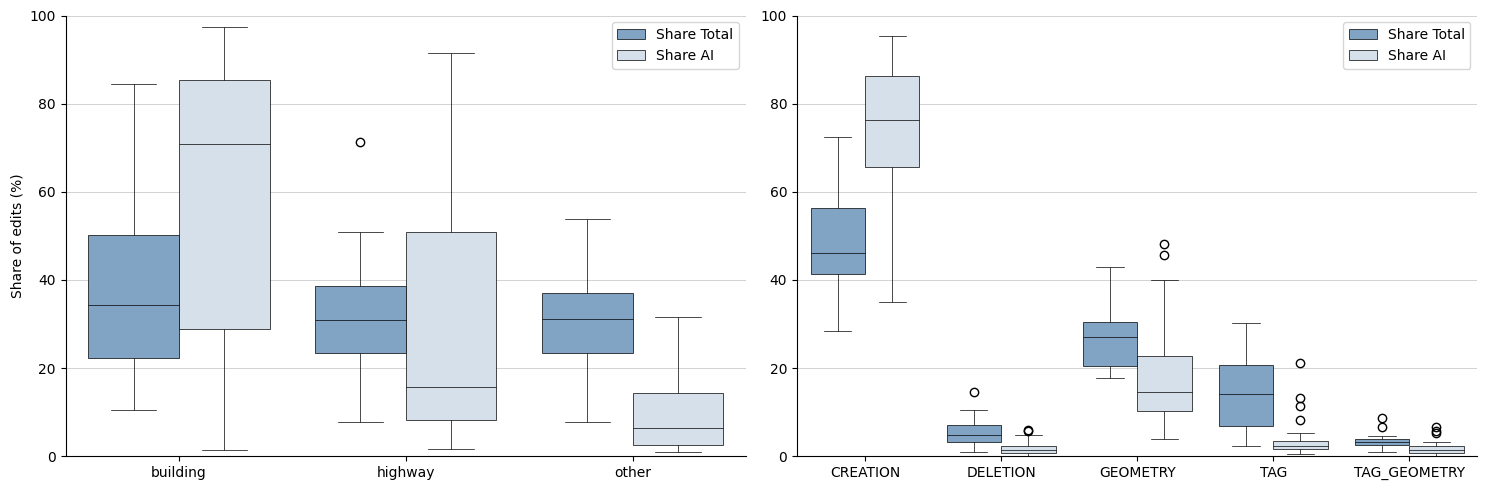

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax1 = ax[0]
sns.boxplot(
    data=df_long, x='tag_type', y='value', hue='type',
    palette={'Share Total': '#74A5D2', 'Share AI': '#D0E0F0'},
    ax=ax1,
    saturation = 0.7,
    linewidth=0.5,
    linecolor="black"
)
ax1.set_xlabel("")
sns.despine(ax=ax1)
ax1.set_ylabel("Share of edits (%)")
ax1.grid(which='major', linewidth=0.4, axis="y")
ax1.legend(title=None)
ax1.set_ylim(0,100)

ax2 = ax[1]
sns.boxplot(
    data=df_longc, x='contrib_type', y='value', hue='type',
    palette={'Share Total': '#74A5D2', 'Share AI': '#D0E0F0'},
    ax=ax2,
    saturation = 0.7,
    linewidth=0.5,
    linecolor="black"
)
ax2.set_xlabel("")
ax2.set_ylabel("")
sns.despine(ax=ax2)
ax2.grid(which='major', linewidth=0.4, axis="y")
ax2.legend(title=None)
ax2.set_ylim(0,100)
#ax.set_title("Feature edit share: Non-AI vs AI edits across 31 countries")
fig.savefig("../../results/contribution_feature_type_31_countries_bplot_v3_top25.png", bbox_inches="tight", dpi=300)
plt.tight_layout()

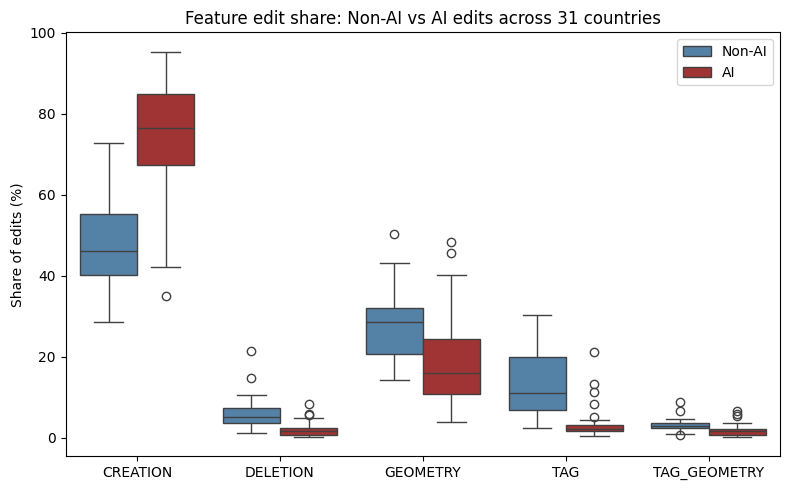

In [178]:
df_longc = all_contribution.melt(
    id_vars=['contrib_type', 'country'],
    value_vars=['share_edit_total', 'share_edit_ai'],
    var_name='type',
    value_name='value'
)

df_longc['type'] = df_longc['type'].map({
    'share_edit_total': 'Non-AI',
    'share_edit_ai': 'AI'
})

order = ['CREATION', 'DELETION', 'GEOMETRY', "TAG", "TAG_GEOMETRY"]
df_longc['contrib_type'] = pd.Categorical(df_longc['contrib_type'], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_longc, x='contrib_type', y='value', hue='type',
    palette={'Non-AI': 'steelblue', 'AI': 'firebrick'},
    ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Share of edits (%)")
ax.set_title("Feature edit share: Non-AI vs AI edits across 31 countries")
ax.legend(title=None)
plt.tight_layout()

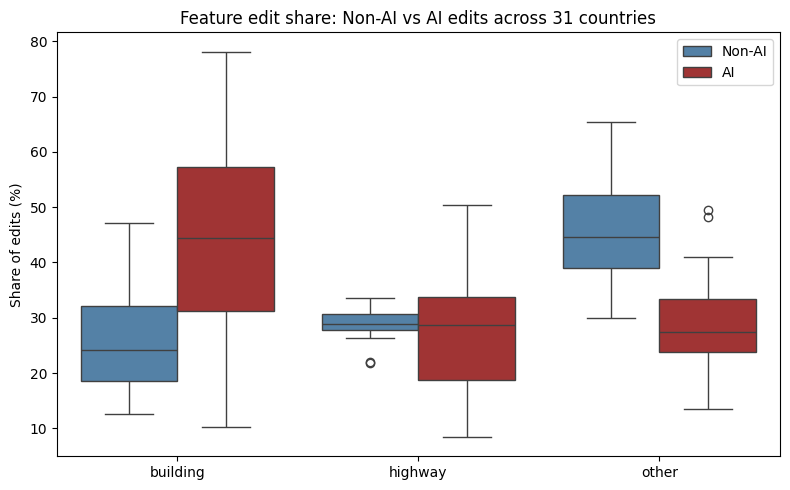

In [177]:
df_long = all_feature.melt(
    id_vars=['tag_type', 'country'],
    value_vars=['share_contrib_total', 'share_contributor_ai'],
    var_name='type',
    value_name='value'
)

df_long['type'] = df_long['type'].map({
    'share_contrib_total': 'Non-AI',
    'share_contributor_ai': 'AI'
})

order = ['building', 'highway', 'other']
df_long['tag_type'] = pd.Categorical(df_long['tag_type'], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_long, x='tag_type', y='value', hue='type',
    palette={'Non-AI': 'steelblue', 'AI': 'firebrick'},
    ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Share of edits (%)")
ax.set_title("Feature edit share: Non-AI vs AI edits across 31 countries")
ax.legend(title=None)
plt.tight_layout()

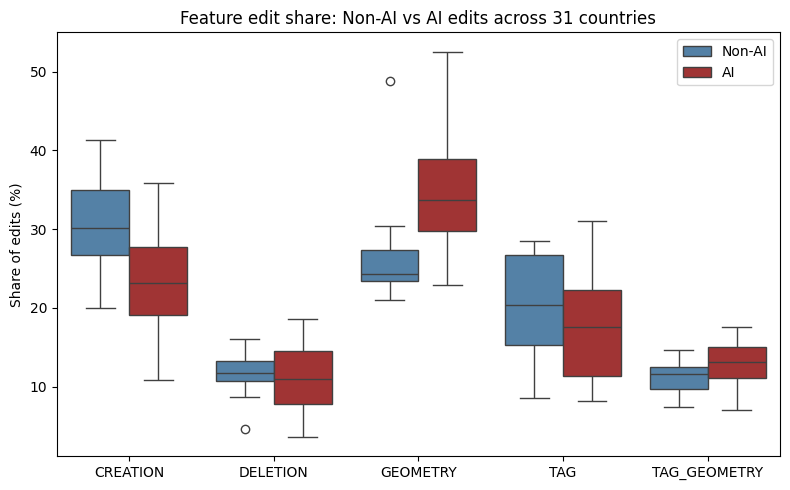

In [183]:
df_longc = all_contribution.melt(
    id_vars=['contrib_type', 'country'],
    value_vars=['share_contrib_total', 'share_contributor_ai'],
    var_name='type',
    value_name='value'
)

df_longc['type'] = df_longc['type'].map({
    'share_contrib_total': 'Non-AI',
    'share_contributor_ai': 'AI'
})

order = ['CREATION', 'DELETION', 'GEOMETRY', "TAG", "TAG_GEOMETRY"]
df_longc['contrib_type'] = pd.Categorical(df_longc['contrib_type'], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_longc, x='contrib_type', y='value', hue='type',
    palette={'Non-AI': 'steelblue', 'AI': 'firebrick'},
    ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Share of edits (%)")
ax.set_title("Feature edit share: Non-AI vs AI edits across 31 countries")
ax.legend(title=None)
plt.tight_layout()